# Chapter 8: Feature Importance

**AFML Ch. 8** -- MDI, MDA, and SFI methods for understanding feature relevance.

Standard feature importance metrics from machine learning (e.g., Gini importance)
can be misleading in finance. This chapter introduces three complementary methods
and shows how PCA can orthogonalize features before analysis.

This notebook demonstrates:

- `make_classification` with known informative, redundant, and noise features
- Mean Decrease Impurity (MDI)
- Mean Decrease Accuracy (MDA)
- Single Feature Importance (SFI)
- Orthogonal features via PCA
- Cross-method importance ranking comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymlfinance

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 15
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13

np.random.seed(42)

## Generate Synthetic Data with Known Feature Structure

We create a dataset where features 0-2 are informative (carry real signal),
features 3-4 are redundant (linear combinations of informative features),
and features 5-9 are pure noise. This lets us verify that importance methods
correctly identify the signal.

In [2]:
X, y = pymlfinance.modeling.make_classification(
    n_samples=500,
    n_informative=3,
    n_redundant=2,
    n_noise=5,
    seed=42
)
n_features = X.shape[1]
print(f"Dataset: {X.shape[0]} samples, {n_features} features")
print(f"  Informative: features 0-2")
print(f"  Redundant: features 3-4")
print(f"  Noise: features 5-9")

Dataset: 500 samples, 10 features
  Informative: features 0-2
  Redundant: features 3-4
  Noise: features 5-9


In [3]:
# Create events for purged CV
events = [(i, min(i + 10, X.shape[0] - 1)) for i in range(X.shape[0])]

## Mean Decrease Impurity (MDI)

MDI measures feature importance by the weighted impurity decrease across all
splits in a tree ensemble. It is fast but biased toward high-cardinality
and noisy features. Here we simulate tree importances to demonstrate the
aggregation.

In [4]:
n_trees = 50
# Informative features have higher importances
base_importance = np.zeros(n_features)
base_importance[:3] = 0.2   # informative
base_importance[3:5] = 0.1  # redundant
base_importance[5:] = 0.02  # noise

importances_per_tree = []
for _ in range(n_trees):
    tree_imp = base_importance + np.abs(np.random.randn(n_features) * 0.03)
    tree_imp /= tree_imp.sum()  # normalize per tree
    importances_per_tree.append(tree_imp.tolist())

mdi = pymlfinance.modeling.mean_decrease_impurity(importances_per_tree)
for i in range(n_features):
    label = "INFO" if i < 3 else ("REDUN" if i < 5 else "NOISE")
    print(f"  Feature {i} [{label:>5s}]: {mdi[i]:.4f}")

  Feature 0 [ INFO]: 0.1958
  Feature 1 [ INFO]: 0.1976
  Feature 2 [ INFO]: 0.1990
  Feature 3 [REDUN]: 0.1107
  Feature 4 [REDUN]: 0.1107
  Feature 5 [NOISE]: 0.0366
  Feature 6 [NOISE]: 0.0392
  Feature 7 [NOISE]: 0.0357
  Feature 8 [NOISE]: 0.0355
  Feature 9 [NOISE]: 0.0392


## Mean Decrease Accuracy (MDA)

MDA measures importance by permuting each feature and measuring the drop in
out-of-sample accuracy. Unlike MDI, MDA captures feature interactions and
is not biased by cardinality.

In [5]:
class SimpleClassifier:
    def __init__(self):
        self.weights = None
    def fit(self, X, y, sample_weight=None):
        # Simple logistic-like: correlate each feature with y
        self.weights = np.array([np.corrcoef(X[:, j], y)[0, 1] for j in range(X.shape[1])])
        return self
    def predict(self, X):
        scores = X @ self.weights
        return (scores > np.median(scores)).astype(np.int32)

In [6]:
clf = SimpleClassifier()
clf.fit(X, y)
mda = pymlfinance.modeling.mean_decrease_accuracy(clf, X, y.astype(np.float64), seed=42)
for i in range(n_features):
    label = "INFO" if i < 3 else ("REDUN" if i < 5 else "NOISE")
    print(f"  Feature {i} [{label:>5s}]: {mda[i]:>+.4f}")

  Feature 0 [ INFO]: -0.0080
  Feature 1 [ INFO]: +0.0020
  Feature 2 [ INFO]: +0.0560
  Feature 3 [REDUN]: +0.0400
  Feature 4 [REDUN]: +0.0360
  Feature 5 [NOISE]: +0.0020
  Feature 6 [NOISE]: -0.0020
  Feature 7 [NOISE]: +0.0020
  Feature 8 [NOISE]: +0.0000
  Feature 9 [NOISE]: +0.0000


## Single Feature Importance (SFI)

SFI evaluates each feature independently by training a classifier on only that
single feature and measuring cross-validated accuracy. It is the most conservative
method -- it cannot detect feature interactions but avoids substitution effects
entirely.

In [7]:
clf2 = SimpleClassifier()
sfi = pymlfinance.modeling.single_feature_importance(
    clf2, X, y.astype(np.float64), events, n_splits=3
)
for i in range(n_features):
    label = "INFO" if i < 3 else ("REDUN" if i < 5 else "NOISE")
    print(f"  Feature {i} [{label:>5s}]: {sfi[i]:.4f}")

  Feature 0 [ INFO]: 0.2980
  Feature 1 [ INFO]: 0.2660
  Feature 2 [ INFO]: 0.4481
  Feature 3 [REDUN]: 0.3641
  Feature 4 [REDUN]: 0.3741
  Feature 5 [NOISE]: 0.2400
  Feature 6 [NOISE]: 0.2560
  Feature 7 [NOISE]: 0.2641
  Feature 8 [NOISE]: 0.2601
  Feature 9 [NOISE]: 0.2701


### Feature Importance Comparison

Grouped bar chart comparing all three importance methods side by side.
Features are colored by type (informative, redundant, noise).

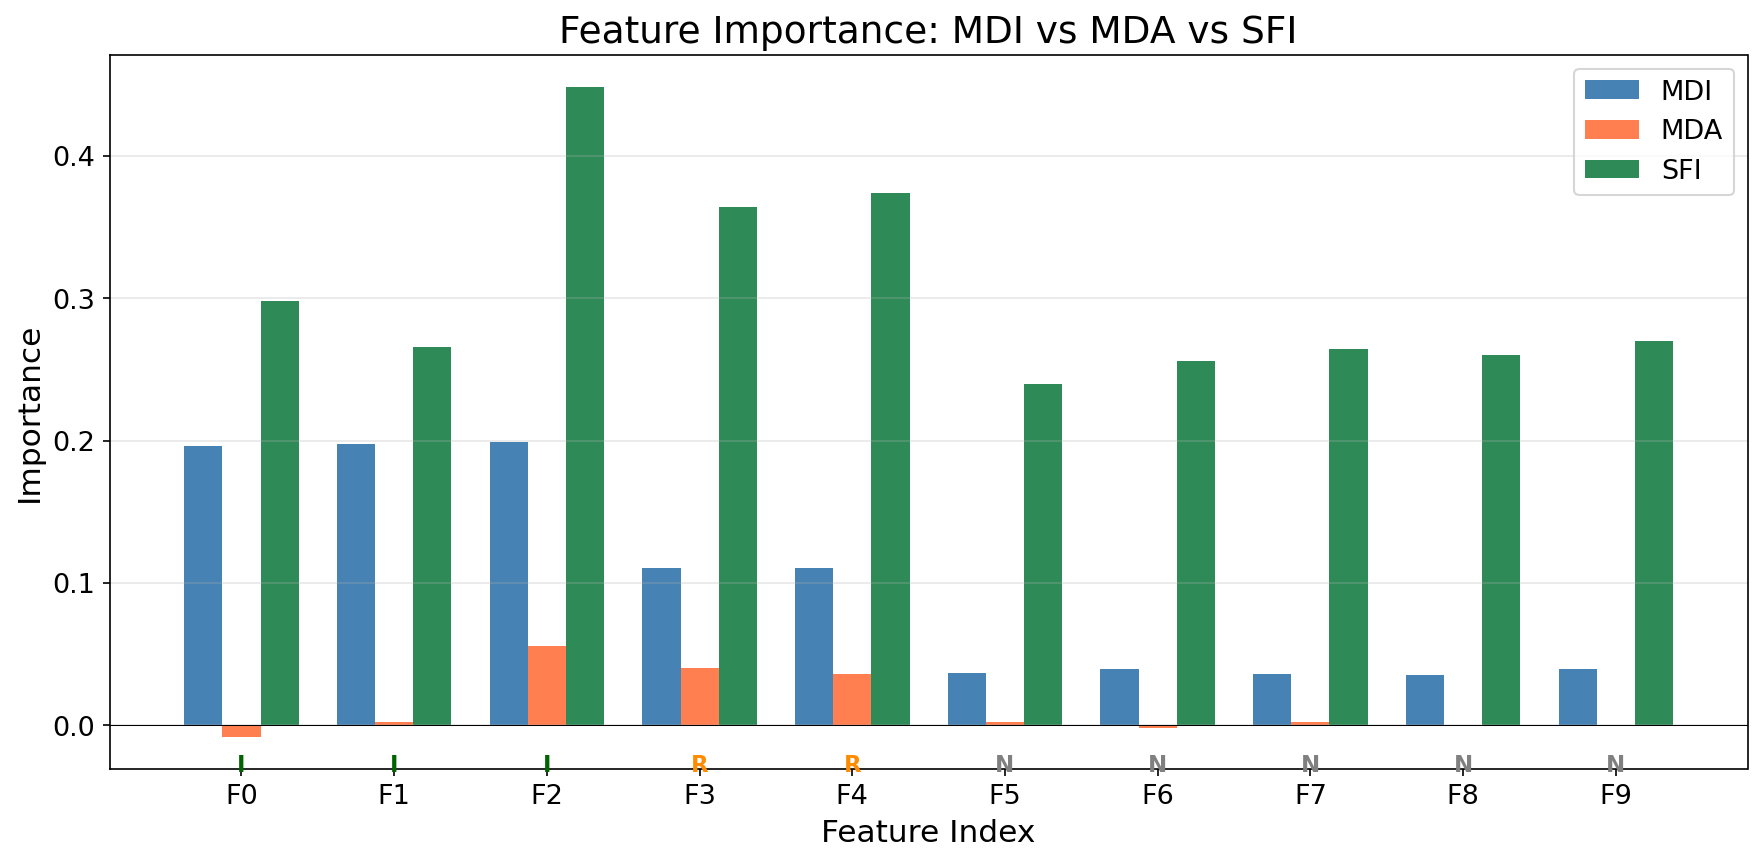

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(n_features)
width = 0.25

bars1 = ax.bar(x - width, mdi, width, label='MDI', color='steelblue')
bars2 = ax.bar(x, mda, width, label='MDA', color='coral')
bars3 = ax.bar(x + width, sfi, width, label='SFI', color='seagreen')

# Add feature type annotations
for i in range(n_features):
    label = "I" if i < 3 else ("R" if i < 5 else "N")
    ax.text(i, -0.02, label, ha='center', va='top', fontsize=11, fontweight='bold',
            color='darkgreen' if i < 3 else ('darkorange' if i < 5 else 'gray'))

ax.set_xlabel('Feature Index')
ax.set_ylabel('Importance')
ax.set_title('Feature Importance: MDI vs MDA vs SFI')
ax.set_xticks(x)
ax.set_xticklabels([f'F{i}' for i in range(n_features)])
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Orthogonal Features (PCA)

PCA transforms the original (possibly correlated) features into orthogonal
principal components. This removes multicollinearity, which is especially
important for MDI and MDA to work correctly.

In [9]:
transformed, var_ratio = pymlfinance.modeling.orthogonal_features(X, n_components=5)
print(f"Top 5 components explain: {np.sum(var_ratio):.2%} of variance")
for i, vr in enumerate(var_ratio):
    print(f"  PC{i}: {vr:.4f}")
print(f"Transformed shape: {transformed.shape}")

Top 5 components explain: 81.20% of variance
  PC0: 0.4615
  PC1: 0.1384
  PC2: 0.0740
  PC3: 0.0697
  PC4: 0.0684
Transformed shape: (500, 5)


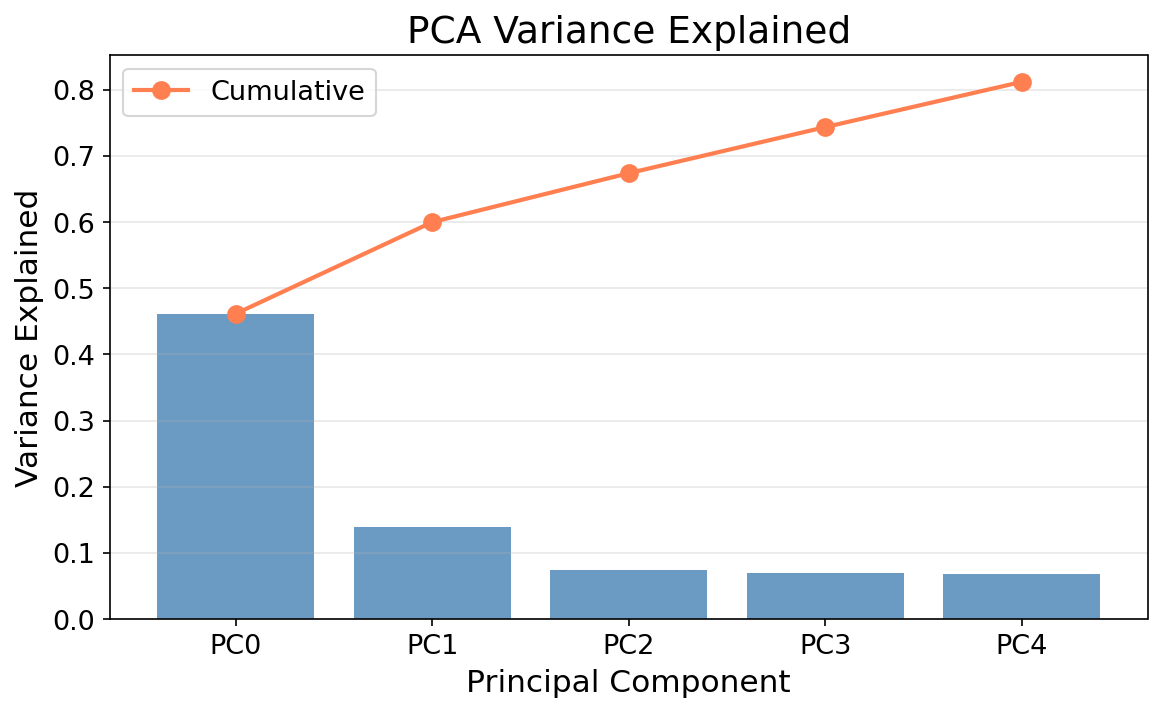

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

pc_indices = np.arange(len(var_ratio))
ax.bar(pc_indices, var_ratio, color='steelblue', alpha=0.8)
ax.plot(pc_indices, np.cumsum(var_ratio), 'o-', color='coral', linewidth=2, markersize=8,
        label='Cumulative')

ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax.set_title('PCA Variance Explained')
ax.set_xticks(pc_indices)
ax.set_xticklabels([f'PC{i}' for i in range(len(var_ratio))])
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Importance Ranking Comparison

Comparing how each method ranks the features. Ideally, all three methods
should rank informative features (0-2) highest and noise features (5-9) lowest.

In [11]:
mdi_rank = np.argsort(-mdi)
mda_rank = np.argsort(-mda)
sfi_rank = np.argsort(-sfi)
print(f"{'Feature':<10} {'MDI Rank':>10} {'MDA Rank':>10} {'SFI Rank':>10}")
for i in range(n_features):
    mdi_r = np.where(mdi_rank == i)[0][0] + 1
    mda_r = np.where(mda_rank == i)[0][0] + 1
    sfi_r = np.where(sfi_rank == i)[0][0] + 1
    print(f"Feature {i:<3d} {mdi_r:>10d} {mda_r:>10d} {sfi_r:>10d}")

Feature      MDI Rank   MDA Rank   SFI Rank
Feature 0            3         10          4
Feature 1            2          4          6
Feature 2            1          1          1
Feature 3            4          2          3
Feature 4            5          3          2
Feature 5            8          6         10
Feature 6            7          9          9
Feature 7            9          5          7
Feature 8           10          8          8
Feature 9            6          7          5


## Exercises

1. Increase noise features and observe how MDI becomes unreliable
2. Compare MDA with a better classifier vs a weak one
3. Use orthogonal features as input and re-run importance analysis